# Data preprocessing
In the following codeblocks, we will preprocess the date for the fine-tuning of GLiNER2. These are the steps we will follow:
1. Filter the Label Studio annotations (only the most recent and validated annotations)
2. Reduce the dataset (optional, to speed up training)
3. Convert the Label Studio annotations to GLiNER2 training data format
4. split the data into training, validation and test sets

### 1. filter the Label Studio annotations

Label Studio only allows to output all the annotations (so also the different annotations for the same text). Firt you need to make sure that you only have those annotations that you need to train the model. In this code snippet, we filter the annotations to only include those that are relevant to us (the most recent and validated annotations). We do this by filtering on the text "id" and "annotator".

In [3]:
import json

# Load your JSON data from the specified input file
with open("LS_Labeled_BHF.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Define ID ranges
id_ranges = [
    range(11317, 11617)  # 11317–11616  -> last number is exclusive
]

# Define allowed annotators
allowed_annotators = {17, 18, 19}

# Filter the data
filtered_data = [
    item for item in data
    if any(item["id"] in r for r in id_ranges)
    and item.get("annotator") in allowed_annotators
]

# Save the filtered JSON to the specified output file
with open("LS_labeled_BHF_filtered.json", "w", encoding="utf-8") as f:
    json.dump(filtered_data, f, ensure_ascii=False, indent=2)

print(f"Filtered {len(filtered_data)} items out of {len(data)} total.")

Filtered 300 items out of 999 total.


### 2. reduce the dataset (optional)

In [2]:
# reducing the dataset

import json
import random

# Paths
input_path = "LS_labeled_BHF_filtered.json"


# Load the JSON file
with open(input_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Set the fraction of entries to keep (0.5 = 50%)
fraction_to_keep = 0.5
num_to_keep = int(len(data) * fraction_to_keep)

# Randomly select entries to keep
reduced_data = random.sample(data, num_to_keep)

output_path = f"LS_labeled_BHF_reduced_{fraction_to_keep}.json"

# Save the reduced JSON
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(reduced_data, f, ensure_ascii=False, indent=2)

print(f"Reduced from {len(data)} entries to {len(reduced_data)} entries.")

Reduced from 190 entries to 95 entries.


### 3. Label Studio to GLiNER2 Training Data Conversion
This code is used to convert the human labeled entities in Label Studio to a format that can be used for training GLiNER2. It reads the labeled data from Label Studio, extracts the relevant information, and creates a new JSON file that can be used for training.
It follows the recommended format:
```json
{"input": "text to process", "output": {"schema_definition": "with_annotations"}}
```

In [1]:
import json
from collections import defaultdict


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def convert_to_gliner2_format(annotation_data, schema):
    """
    Converts Label Studio-style annotations to GLiNER2 format.
    Only uses labels defined inside schema["entities"].
    """

    # ✅ Only take actual NER entity types
    entity_types = list(schema["entities"].keys())

    gliner_data = []

    for item in annotation_data:
        text = item["text"]
        annotations = item.get("label", [])

        entities_dict = defaultdict(list)

        # Collect entities
        for ann in annotations:
            entity_text = ann["text"].strip()
            labels = ann.get("labels", [])

            for label in labels:
                # ✅ Only include labels that exist in schema
                if label in entity_types:
                    entities_dict[label].append(entity_text)

        # Deduplicate while preserving order
        for label in entities_dict:
            seen = set()
            deduped = []
            for ent in entities_dict[label]:
                if ent not in seen:
                    deduped.append(ent)
                    seen.add(ent)
            entities_dict[label] = deduped

        # Ensure ALL schema entity types are present (even if empty)
        for entity_type in entity_types:
            if entity_type not in entities_dict:
                entities_dict[entity_type] = []

        formatted_item = {
            "text": text,
            "entities": dict(entities_dict)
            }


        gliner_data.append(formatted_item)

    return gliner_data


def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


if __name__ == "__main__":
    annotation_file = "LS_labeled_BHF_filtered.json"
    schema_file = "gliner_schema_BelHisFirm.json"
    output_file = "gliner2_data_BHF.json"

    annotations = load_json(annotation_file)
    schema = load_json(schema_file)

    gliner_data = convert_to_gliner2_format(annotations, schema)
    save_json(gliner_data, output_file)

    print(f"Converted {len(gliner_data)} examples.")

Converted 300 examples.


### 4. split the data into training and test sets
To be able to evaluate the performance of our model, we need to split our dataset into training (80%) and test (20%) sets. This code snippet takes the converted GLiNER2 training data and splits it into three separate JSON files for training, validation and testing.

In [2]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 15.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [ ]:
import json
import os
from sklearn.model_selection import train_test_split

# ── Config ────────────────────────────────────────────────────────────────────

INPUT_FILE   = "gliner2_data_BHF.json"
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# ── Load, split and save ──────────────────────────────────────────────────────

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)

os.makedirs("./data", exist_ok=True)

with open("./data/train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, indent=2, ensure_ascii=False)

with open("./data/test.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, indent=2, ensure_ascii=False)

print(f"Total:  {len(data)} examples")
print(f"Train:  {len(train_data)} examples ({(1 - TEST_SIZE)*100:.0f}%)")
print(f"Test:   {len(test_data)} examples ({TEST_SIZE*100:.0f}%)")
print(f"\n📁 Saved to ./data/train.json and ./data/test.json")

# Finetuning GLiNER2 with LoRA
Now that we have the training data in the correct format, we can use it to fine-tune GLiNER2 specifically for our use case.

For LoRA training, you essentially have two options:
1. Train a single adapter on all the entity types together
2. Train separate adapters for different groups of entity types (multi-domain adapter)

We will go trough both options, starting with the single adapter training and then moving on to the multi-domain adapter training.

# 1. single adapter training

In [1]:
!pip install gliner2

## Step 1: prepare Domain-Specific Data
We have already prepared our training data in the previous step. The file `train.json` contains the text and corresponding entities in the format required for GLiNER2 training. Now we can load this data and use it for fine-tuning the model.

In [1]:
import json
from gliner2.training.data import InputExample

with open("./data/train.json", "r", encoding="utf-8") as f:
    data = json.load(f)

train_data = [
    InputExample(text=item["text"], entities=item["entities"])
    for item in data
]

## Step 2: Set Up LoRA Training
Next, we will set up the LoRA training configuration. This involves specifying the adaptor we want to train, the training parameters and the LoRA settings.

In [2]:
from gliner2 import GLiNER2
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig

# LoRA configuration
config = TrainingConfig(
    output_dir="./BelHisFirm_adaptor_2",       # change this to your desired output directory
    experiment_name="BelHisFirm",            # change this to your desired experiment name

    # Training parameters
    num_epochs=10,
    batch_size=8,
    gradient_accumulation_steps=2,
    encoder_lr=1e-5,
    task_lr=5e-4,

    # LoRA settings
    use_lora=True,                              # Enable LoRA
    lora_r=8,                                   # Rank (4, 8, 16, 32)
    lora_alpha=16.0,                           # Scaling factor (usually 2*r)
    lora_dropout=0.0,                          # Dropout for LoRA layers
    lora_target_modules=["encoder"],           # Apply to all encoder layers (query, key, value, dense)
    save_adapter_only=True,                    # Save only adapter (not full model)

    # Optimization
    eval_strategy="epoch",  # Evaluates and saves at end of each epoch
    eval_steps=500,  # Used when eval_strategy="steps"
    logging_steps=50,
    fp16=True,  # Use mixed precision if GPU available
)

## Step 3: Train the LoRA Adaptor
Now we can initialize the GLiNER2 model and the trainer, and start the training process

In [3]:
# Load base model
base_model = GLiNER2.from_pretrained("fastino/gliner2-base-v1")

# Create trainer
trainer = GLiNER2Trainer(model=base_model, config=config)

# Train adapter
trainer.train(train_data=train_data)

# Adapter automatically saved to ./BelHisFirm_adapter/final/

You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first


2026-04-13 15:35:32 - INFO - gliner2.training.trainer - Setting up LoRA for parameter-efficient fine-tuning...
2026-04-13 15:35:32 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training
2026-04-13 15:35:32 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 15:35:32 - INFO - gliner2.training.trainer - LoRA setup complete: 1,327,104 trainable params out of 209,803,925 total (0.63%)


🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 8
Alpha              : 16.0
Scaling (α/r)      : 2.0000
Dropout            : 0.0
Target modules     : encoder
LoRA layers        : 72
----------------------------------------------------------------------
Trainable params   : 1,327,104 / 209,803,925 (0.63%)
Memory savings     : ~99.4% fewer gradients


Validating records: 100%|██████████| 240/240 [00:00<00:00, 11944.05record/s]
2026-04-13 15:35:32 - INFO - gliner2.training.trainer - Optimizer: LoRA params only = 144, LR=0.0005
/home/hbekaer/PycharmProjects/ghentcdh-glinerv2-tutorial/.venv/lib/python3.13/site-packages/gliner2/training/trainer.py:900: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=self.config.fp16)
2026-04-13 15:35:32 - INFO - gliner2.training.trainer - ***** Running Training *****
2026-04-13 15:35:32 - INFO - gliner2.training.trainer -   Num examples = 240
2026-04-13 15:35:32 - INFO - gliner2.training.trainer -   Num epochs = 10
2026-04-13 15:35:32 - INFO - gliner2.training.trainer -   Batch size = 8
2026-04-13 15:35:32 - INFO - gliner2.training.trainer -   Gradient accumulation steps = 2
2026-04-13 15:35:32 - INFO - gliner2.training.trainer -   Effective batch size = 16
2026-04-13 15:35:32 - INFO - gline

Training:   0%|          | 0/150 [00:00<?, ?it/s]

/home/hbekaer/PycharmProjects/ghentcdh-glinerv2-tutorial/.venv/lib/python3.13/site-packages/gliner2/training/trainer.py:947: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp, dtype=amp_dtype):
2026-04-13 15:35:33 - WARNING - gliner2.training.trainer - OOM at step 1, batch skipped. Consider reducing batch_size or max sequence length.
2026-04-13 15:35:34 - WARNING - gliner2.training.trainer - OOM at step 2, batch skipped. Consider reducing batch_size or max sequence length.
/home/hbekaer/PycharmProjects/ghentcdh-glinerv2-tutorial/.venv/lib/python3.13/site-packages/gliner2/training/trainer.py:993: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate sch

KeyboardInterrupt: 

## Step 4: evaluate the trained adapter
After training, we can evaluate the performance of our trained adapter on the validation and test sets. We will load the trained adapter, run it on the validation and test data, and calculate evaluation metrics such as precision, recall and F1-score for the extracted entities. This will help us understand how well our adapter is performing on unseen data and whether it has successfully learned to extract the relevant entities for our specific use case.

In [33]:
import json
import pandas as pd
from gliner2 import GLiNER2

# ── Config ────────────────────────────────────────────────────────────────────

BASE_MODEL   = "fastino/gliner2-base-v1"
ADAPTER_PATH = "./BelHisFirm_adaptor/final"
TEST_FILE    = "./data/test.json"

ENTITY_TYPES = [
    "city", "street_address", "corporate_position", "capital_category",
    "legal_structure", "deed_number", "date", "archive_reference",
    "office_type", "organization_name", "share_nominal_value",
    "business_activity", "share_class", "occupation", "legal_act",
    "number_of_shares", "corporate_body", "time_period", "building_name",
    "country", "person", "honorific_title", "number_of_votes",
]

# ── Load test data ────────────────────────────────────────────────────────────

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

# ── Per-entity metrics helper ─────────────────────────────────────────────────

def compute_per_entity_metrics(pred_entities_dict, true_entities_dict, entity_types):
    metrics = {}
    for label in entity_types:
        true_spans = {s.lower().strip() for s in true_entities_dict.get(label, [])}
        pred_spans = {s.lower().strip() for s in pred_entities_dict.get(label, [])}

        tp = len(pred_spans & true_spans)
        fp = len(pred_spans - true_spans)
        fn = len(true_spans - pred_spans)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0

        metrics[label] = {"precision": precision, "recall": recall, "f1": f1,
                          "tp": tp, "fp": fp, "fn": fn}
    return metrics

# ── Evaluate ──────────────────────────────────────────────────────────────────

model = GLiNER2.from_pretrained(BASE_MODEL)

# Accumulate per-entity totals across all samples
all_results = {}

for run_label, load_adapter in [("Base", False), ("Adapter", True)]:
    if load_adapter:
        model.load_adapter(ADAPTER_PATH)
    else:
        model.unload_adapter()

    # Accumulators: tp, fp, fn per entity type
    accum = {e: {"tp": 0, "fp": 0, "fn": 0} for e in ENTITY_TYPES}

    for sample in test_data:
        entity_types = list(sample["entities"].keys())
        pred = model.extract_entities(sample["text"], entity_types)
        per_entity = compute_per_entity_metrics(
            pred["entities"], sample["entities"], ENTITY_TYPES
        )
        for label, m in per_entity.items():
            accum[label]["tp"] += m["tp"]
            accum[label]["fp"] += m["fp"]
            accum[label]["fn"] += m["fn"]

    all_results[run_label] = accum
    print(f"✅ {run_label} evaluated")

# ── Build table ───────────────────────────────────────────────────────────────

def accum_to_metrics(accum_dict):
    rows = []
    total_tp = total_fp = total_fn = 0

    for label in ENTITY_TYPES:
        tp = accum_dict[label]["tp"]
        fp = accum_dict[label]["fp"]
        fn = accum_dict[label]["fn"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        rows.append({
            "Entity":    label,
            "Precision": round(precision, 4),
            "Recall":    round(recall,    4),
            "F1":        round(f1,        4),
            "TP":        tp,
            "FP":        fp,
            "FN":        fn,
        })

    # Overall row
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Entity":    "OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
        "TP":        total_tp,
        "FP":        total_fp,
        "FN":        total_fn,
    })
    return pd.DataFrame(rows)

df_base    = accum_to_metrics(all_results["Base"])
df_adapter = accum_to_metrics(all_results["Adapter"])

# Merge into one table with suffixes
df = df_base.merge(df_adapter, on="Entity", suffixes=(" (Base)", " (Adapter)"))

# ── Style and display ─────────────────────────────────────────────────────────

def highlight_rows(row):
    if row["Entity"] == "OVERALL":
        return ["font-weight: bold; background-color: #f0f0f0"] * len(row)
    return [""] * len(row)

def highlight_better_f1(row):
    styles = [""] * len(row)
    base_f1    = row["F1 (Base)"]
    adapter_f1 = row["F1 (Adapter)"]
    f1_base_idx    = row.index.get_loc("F1 (Base)")
    f1_adapter_idx = row.index.get_loc("F1 (Adapter)")
    if adapter_f1 > base_f1:
        styles[f1_adapter_idx] = "color: green; font-weight: bold"
        styles[f1_base_idx]    = "color: red"
    elif base_f1 > adapter_f1:
        styles[f1_base_idx]    = "color: green; font-weight: bold"
        styles[f1_adapter_idx] = "color: red"
    return styles

fmt = {c: "{:.4f}" for c in df.columns if any(m in c for m in ["Precision", "Recall", "F1"])}

df.style \
  .apply(highlight_rows,       axis=1) \
  .apply(highlight_better_f1,  axis=1) \
  .format(fmt) \
  .set_caption("GLiNER2 — Base vs Adapter: per-entity evaluation") \
  .set_table_styles([{"selector": "caption",
                      "props": [("font-size", "14px"), ("font-weight", "bold")]}])

2026-04-13 14:09:58 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 14:09:58 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-base-v1/283f4af5e598631a5352b8c388b6906853146f07/config.json "HTTP/1.1 200 OK"
2026-04-13 14:09:59 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 14:09:59 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-base-v1/283f4af5e598631a5352b8c388b6906853146f07/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-13 14:09:59 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-base-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 14:09:59 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/r

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first


2026-04-13 14:10:23 - INFO - gliner2.training.lora - Loaded 144 LoRA tensors from BelHisFirm_adaptor/final/adapter_weights.safetensors
2026-04-13 14:10:23 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 14:10:23 - INFO - gliner2.training.lora - Loaded LoRA adapter from BelHisFirm_adaptor/final


✅ Base evaluated
✅ Adapter evaluated


,Entity,Precision (Base),Recall (Base),F1 (Base),TP (Base),FP (Base),FN (Base),Precision (Adapter),Recall (Adapter),F1 (Adapter),TP (Adapter),FP (Adapter),FN (Adapter)
0,city,0.9365,0.7564,0.8369,59,4,19,0.9444,0.8718,0.9067,68,4,10
1,street_address,0.2414,0.4667,0.3182,7,22,8,0.9333,0.9333,0.9333,14,1,1
2,corporate_position,0.5849,0.2168,0.3163,31,22,112,0.7484,0.8322,0.7881,119,40,24
3,capital_category,0.5455,0.7500,0.6316,6,5,2,0.8750,0.8750,0.8750,7,1,1
4,legal_structure,0.0263,0.0312,0.0286,1,37,31,0.7742,0.7500,0.7619,24,7,8
5,deed_number,0.0000,0.0000,0.0000,0,10,3,1.0000,0.6667,0.8000,2,0,1
6,date,0.9167,0.6168,0.7374,66,6,41,0.8018,0.8318,0.8165,89,22,18
7,archive_reference,0.0500,0.0500,0.0500,1,19,19,1.0000,1.0000,1.0000,20,0,0
8,office_type,0.0588,0.1250,0.0800,1,16,7,1.0000,0.8750,0.9333,7,0,1
9,organization_name,0.1000,0.0851,0.0920,4,36,43,0.5385,0.4468,0.4884,21,18,26


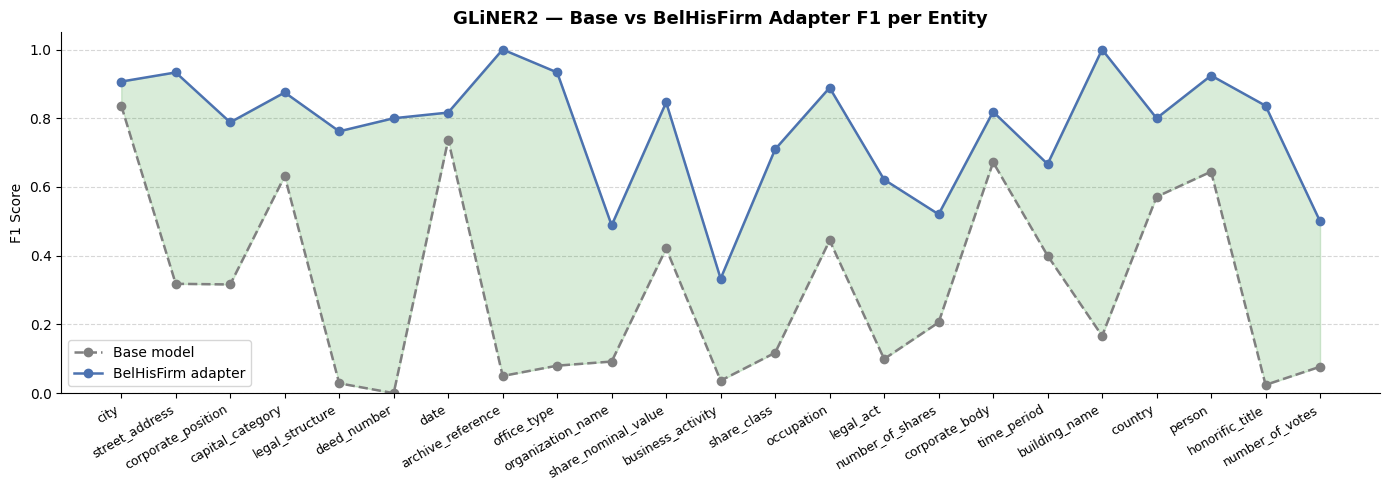

✅ Saved to f1_comparison_belhisfirm.png


In [34]:
## make a graph to compare the F1 score

import matplotlib.pyplot as plt
import numpy as np

# ── Pull F1 scores from existing df ──────────────────────────────────────────

df_plot = df[~df["Entity"].str.contains("OVERALL")].copy()

labels  = df_plot["Entity"].tolist()
x       = np.arange(len(labels))

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, df_plot["F1 (Base)"],    color="gray",    marker="o",
        linewidth=1.8, markersize=6, linestyle="--", label="Base model")
ax.plot(x, df_plot["F1 (Adapter)"], color="#4C72B0", marker="o",
        linewidth=1.8, markersize=6, linestyle="-",  label="BelHisFirm adapter")

# Shade green where adapter wins, red where it doesn't
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values >= df_plot["F1 (Base)"].values,
    alpha=0.15, color="green"
)
ax.fill_between(
    x,
    df_plot["F1 (Base)"].values,
    df_plot["F1 (Adapter)"].values,
    where=df_plot["F1 (Adapter)"].values < df_plot["F1 (Base)"].values,
    alpha=0.15, color="red"
)

ax.set_title("GLiNER2 — Base vs BelHisFirm Adapter F1 per Entity",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("f1_comparison_belhisfirm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to f1_comparison_belhisfirm.png")

#
---

## 2. multi-domain adapter training

## Step 0: prepare the domain-specific data
When training a GLiNER2 adaptor it is advised to train different adaptors for several domains within you NER project. This means that you divide your NER labels into different groups (for example: address entities, person entities, organization entities, etc.) and train a separate adaptor for each group. This way you can ensure that the model learns to extract the relevant entities for each specific domain in an efficient way. For our example we will use the following domains:
1. date: "date" + "time_period"
2. organisation: "organization_name", "corporate_body", "legal_structure", "office_type"
3. legal: "legal_act", "deed_number", "archive_reference"
4. person: "person", "honorific_title", "occupation", "corporate_position"
5. share: "number_of_shares", "share_class", "share_nominal_value", "capital_category", "number_of_votes"
6. location: "country", "city", "street_address", "building_name"

In this preparatory step, we will filter our training data to only include the entities of a specific domain (for example: organisation entities)

In [5]:
import json
from pathlib import Path
from typing import List, Dict, Any


def filter_dataset_by_labels(
    data: List[Dict[str, Any]],
    allowed_labels: List[str],
    drop_empty: bool = True,
    keep_all_keys: bool = True
) -> List[Dict[str, Any]]:
    if isinstance(allowed_labels, str):
        allowed_labels = [allowed_labels]

    # Keep order and remove duplicates/spaces from user input.
    allowed_labels = [label.strip() for label in allowed_labels if str(label).strip()]
    allowed_labels = list(dict.fromkeys(allowed_labels))

    if not allowed_labels:
        raise ValueError("allowed_labels must contain at least one label.")

    filtered_data = []

    for sample in data:
        text = sample["text"]
        entities = sample.get("entities", {})

        if keep_all_keys:
            new_entities = {
                label: entities.get(label, [])
                for label in allowed_labels
            }
        else:
            new_entities = {
                label: entities[label]
                for label in allowed_labels
                if label in entities and len(entities[label]) > 0
            }

        has_entities = any(len(v) > 0 for v in new_entities.values())

        if not drop_empty or has_entities:
            filtered_data.append({
                "text": text,
                "entities": new_entities
            })

    return filtered_data


def save_filtered_dataset(
    input_path: str,
    output_path: str,
    allowed_labels: List[str],
    drop_empty: bool = True,
    keep_all_keys: bool = False
):
    """
    Loads dataset, filters it, and saves to a new JSON file.
    """

    # Load dataset
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Filter dataset
    filtered_data = filter_dataset_by_labels(
        data,
        allowed_labels=allowed_labels,
        drop_empty=drop_empty,
        keep_all_keys=keep_all_keys
    )

    # Save new dataset
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(filtered_data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(filtered_data)} samples to {output_path}")




In [11]:
# define you domains and subsequent labels
DOMAIN_LABELS = {
    "date": ["date", "time_period"],
    "organisation": ["organization_name", "corporate_body","legal_structure", "office_type"],
    "legal": ["legal_act", "deed_number", "archive_reference"],
    "person": ["person", "honorific_title", "occupation", "corporate_position"],
    "share": ["number_of_shares", "share_class", "share_nominal_value", "capital_category", "number_of_votes"],
    "location": ["country", "city", "street_address", "building_name"]}

# Choose domain
selected_domain = "location"  # change this to the domain you want to filter for

save_filtered_dataset(
    input_path="./data/test.json",
    output_path=f"./data/test_{selected_domain}.json",
    allowed_labels=DOMAIN_LABELS[selected_domain],
    drop_empty=True,
    keep_all_keys=True,
)

Saved 37 samples to ./data/test_location.json


### Optional: reduce the dataset

In [7]:
import json
import os
import random

# ── Config ────────────────────────────────────────────────────────────────────

DOMAIN_FILES = {
    "date":         "./data/train_date.json",
    "organisation": "./data/train_organisation.json",
    "legal":        "./data/train_legal.json",
    "person":       "./data/train_person.json",
    "share":        "./data/train_share.json",
    "location":     "./data/train_location.json",
}

# ── Set your desired fraction here ───────────────────────────────────────────

FRACTION = 0.33   # <-- change this to whatever fraction you want (0.0 - 1.0)

# ── Create output folder ──────────────────────────────────────────────────────

fraction_label = f"{int(FRACTION * 100)}pct"
output_dir = f"./data/reduced_{fraction_label}"
os.makedirs(output_dir, exist_ok=True)

# ── Reduce and save ───────────────────────────────────────────────────────────

for domain, file_path in DOMAIN_FILES.items():
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    original_size = len(data)
    sample_size   = max(1, int(original_size * FRACTION))
    reduced       = random.sample(data, sample_size)

    output_path = f"{output_dir}/train_{domain}.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(reduced, f, indent=2, ensure_ascii=False)

    print(f"✅ {domain}: {original_size} → {len(reduced)} samples ({FRACTION*100:.0f}%) saved to {output_path}")

print(f"\n📁 All reduced files saved to {output_dir}/")

✅ date: 152 → 50 samples (33%) saved to ./data/reduced_33pct/train_date.json
✅ organisation: 161 → 53 samples (33%) saved to ./data/reduced_33pct/train_organisation.json
✅ legal: 140 → 46 samples (33%) saved to ./data/reduced_33pct/train_legal.json
✅ person: 172 → 56 samples (33%) saved to ./data/reduced_33pct/train_person.json
✅ share: 81 → 26 samples (33%) saved to ./data/reduced_33pct/train_share.json
✅ location: 139 → 45 samples (33%) saved to ./data/reduced_33pct/train_location.json

📁 All reduced files saved to ./data/reduced_33pct/


## Step 1: load the domain-specific data

In [2]:
import json
from gliner2.training.data import InputExample

# Map domains to their filtered JSON files
DOMAIN_FILES = {
    "date": "./data/reduced_33pct/train_date.json",
    "organisation": "./data/reduced_33pct/train_organisation.json",
    "legal": "./data/reduced_33pct/train_legal.json",
    "person": "./data/reduced_33pct/train_person.json",
    "share": "./data/reduced_33pct/train_share.json",
    "location": "./data/reduced_33pct/train_location.json"
}


def load_domain_examples(domain_name: str):
    """
    Loads a filtered training dataset for a given domain
    and returns a list of InputExample objects.
    """
    file_path = DOMAIN_FILES.get(domain_name)
    if not file_path:
        raise ValueError(f"No file configured for domain '{domain_name}'.")

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    examples = [
        InputExample(text=item["text"], entities=item["entities"])
        for item in data
    ]

    return examples

# define the domain data
## load the 'date' domain
date_examples = load_domain_examples("date")

## load the 'organisation' domain
organisation_examples = load_domain_examples("organisation")

## load the 'legal' domain
legal_examples = load_domain_examples("legal")

## load the 'person' domain
person_examples = load_domain_examples("person")

## load the 'share' domain
share_examples = load_domain_examples("share")

## load the 'location' domain
location_examples = load_domain_examples("location")


## Step 2: Set Up LoRA Training
Next, we will set up the LoRA training configuration. This involves specifying the adaptor we want to train, the training parameters and the LoRA settings.

In [3]:
import gc
import torch

def train_domain_adapter(
    base_model_name: str,
    examples: list,
    domain_name: str,
    output_dir: str = "./adapters"
):
    """Train a LoRA adapter for a specific domain."""
    adapter_path = f"{output_dir}/{domain_name}_adapter"

    config = TrainingConfig(
        output_dir=adapter_path,
        experiment_name=f"{domain_name}_domain",
        num_epochs=10,
        batch_size=1,                      # reduced from 8
        gradient_accumulation_steps=4,     # increased to compensate (effective batch = 16)
        encoder_lr=1e-5,
        task_lr=5e-4,
        use_lora=True,
        lora_r=4,                         # reduced from 8
        lora_alpha=16.0,
        lora_dropout=0.0,
        lora_target_modules=["encoder.query", "encoder.key", "encoder.value"],
        save_adapter_only=True,
        eval_strategy="epoch",
        eval_steps=500,
        logging_steps=50,
        fp16=True,
    )

    print(f"\n{'='*60}")
    print(f"Training {domain_name.upper()} adapter")
    print(f"{'='*60}")

    model = GLiNER2.from_pretrained(base_model_name)
    trainer = GLiNER2Trainer(model=model, config=config)
    results = trainer.train(train_data=examples)

    final_path = f"{adapter_path}/final"
    print(f"\n✅ {domain_name.capitalize()} adapter trained!")
    print(f"📁 Saved to: {final_path}/")
    print(f"⏱️  Training time: {results['total_time_seconds']:.2f}s")

    # ✅ Explicitly free GPU memory before the next domain
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

    return final_path

## step 3: train all the domain-specific adapters

In [4]:
from gliner2 import GLiNER2
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig

if __name__ == "__main__":
    BASE_MODEL = "fastino/gliner2-multi-v1"

    DOMAINS = ["date", "legal", "organisation", "location", "share", "person"]

    adapter_paths = {}
    for domain in DOMAINS:
        examples = load_domain_examples(domain)   # load only when needed
        adapter_paths[domain] = train_domain_adapter(BASE_MODEL, examples, domain)
        del examples                               # free RAM too
        gc.collect()

    print("\n" + "="*60)
    print("🎉 All adapters trained successfully!")
    print("="*60)
    for domain, path in adapter_paths.items():
        print(f"{domain.capitalize()} adapter: {path}")


Training DATE adapter


You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-13 15:13:00 - INFO - gliner2.training.trainer - Setting up LoRA for parameter-efficient fine-tuning...
2026-04-13 15:13:00 - INFO - gliner2.training.trainer - Froze all model parameters for LoRA training
2026-04-13 15:13:00 - INFO - gliner2.training.lora - Applied LoRA to 36 layers
2026-04-13 15:13:00 - INFO - gliner2.training.trainer - LoRA setup complete: 221,184 trainable params out of 307,319,829 total (0.07%)


🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 4
Alpha              : 16.0
Scaling (α/r)      : 4.0000
Dropout            : 0.0
Target modules     : encoder.query, encoder.key, encoder.value
LoRA layers        : 36
----------------------------------------------------------------------
Trainable params   : 221,184 / 307,319,829 (0.07%)
Memory savings     : ~99.9% fewer gradients


...

🔧 LoRA Configuration
Enabled            : True
Rank (r)           : 4
Alpha              : 16.0
Scaling (α/r)      : 4.0000
Dropout            : 0.0
Target modules     : encoder.query, encoder.key, encoder.value
LoRA layers        : 36
----------------------------------------------------------------------
Trainable params   : 221,184 / 307,319,829 (0.07%)
Memory savings     : ~99.9% fewer gradients


Validating records: 100%|██████████| 56/56 [00:00<00:00, 17455.49record/s]
2026-04-13 15:14:44 - INFO - gliner2.training.trainer - Optimizer: LoRA params only = 72, LR=0.0005
2026-04-13 15:14:44 - INFO - gliner2.training.trainer - ***** Running Training *****
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Num examples = 56
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Num epochs = 10
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Batch size = 1
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Gradient accumulation steps = 4
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Effective batch size = 4
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Total optimization steps = 140
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   Warmup steps = 14
2026-04-13 15:14:44 - INFO - gliner2.training.trainer -   LoRA enabled: 221,184 trainable / 307,319,829 total (0.07%)


Training:   0%|          | 0/140 [00:00<?, ?it/s]

2026-04-13 15:14:47 - INFO - gliner2.training.trainer - Epoch 1/10 - Loss: 15.5689
2026-04-13 15:14:47 - INFO - gliner2.training.lora - Saved 72 LoRA tensors to adapters/person_adapter/checkpoint-epoch-1/adapter_weights.safetensors
2026-04-13 15:14:47 - INFO - gliner2.training.lora - Saved adapter config to adapters/person_adapter/checkpoint-epoch-1/adapter_config.json
2026-04-13 15:14:47 - INFO - gliner2.training.lora - Saved LoRA adapter to adapters/person_adapter/checkpoint-epoch-1
2026-04-13 15:14:47 - INFO - gliner2.training.trainer - 💾 Saved adapter checkpoint 'checkpoint-epoch-1' | step 14 | epoch 1.0 | 221,184 params | 0.9MB | 0.0s
2026-04-13 15:14:47 - INFO - gliner2.training.trainer - Removed old checkpoint: checkpoint-epoch-8
2026-04-13 15:14:49 - INFO - gliner2.training.trainer - Epoch 2/10 - Loss: 11.6273
2026-04-13 15:14:49 - INFO - gliner2.training.lora - Saved 72 LoRA tensors to adapters/person_adapter/checkpoint-epoch-2/adapter_weights.safetensors
2026-04-13 15:14:49 -


✅ Person adapter trained!
📁 Saved to: ./adapters/person_adapter/final/
⏱️  Training time: 24.36s

🎉 All adapters trained successfully!
Date adapter: ./adapters/date_adapter/final
Legal adapter: ./adapters/legal_adapter/final
Organisation adapter: ./adapters/organisation_adapter/final
Location adapter: ./adapters/location_adapter/final
Share adapter: ./adapters/share_adapter/final
Person adapter: ./adapters/person_adapter/final


In [31]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 18.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 13.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 17.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


## evaluation for multi-domain adapters

In [4]:
!install pandas

install: missing destination file operand after 'pandas'
Try 'install --help' for more information.


In [5]:
def compute_metrics(pred_entities_dict, true_entities_dict):
    # Flatten both dicts to sets of (span, label) tuples
    true_set = {
        (span.lower().strip(), label)
        for label, spans in true_entities_dict.items()
        for span in spans
    }
    pred_set = {
        (span.lower().strip(), label)
        for label, spans in pred_entities_dict.items()
        for span in spans
    }

    tp = len(pred_set & true_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {"precision": precision, "recall": recall}


def evaluate_adapter(model, adapter_path, test_data):
    model.load_adapter(adapter_path)

    results = {
        "total":         0,
        "precision_sum": 0,
        "recall_sum":    0,
    }

    for sample in test_data:
        entity_types = list(sample["entities"].keys())
        pred = model.extract_entities(sample["text"], entity_types)

        metrics = compute_metrics(pred["entities"], sample["entities"])
        results["total"]         += 1
        results["precision_sum"] += metrics["precision"]
        results["recall_sum"]    += metrics["recall"]

    avg_precision = results["precision_sum"] / results["total"]
    avg_recall    = results["recall_sum"]    / results["total"]
    f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) \
         if (avg_precision + avg_recall) > 0 else 0.0

    return {
        "precision": avg_precision,
        "recall":    avg_recall,
        "f1":        f1,
        "samples":   results["total"],
    }

In [6]:
import json
import pandas as pd
from gliner2 import GLiNER2

# ── Config ────────────────────────────────────────────────────────────────────

BASE_MODEL = "fastino/gliner2-multi-v1"
OUTPUT_DIR = "./adapters"

DOMAIN_ENTITIES = {
    "date":         ["date", "time_period"],
    "organisation": ["organization_name", "corporate_body", "legal_structure", "office_type"],
    "legal":        ["legal_act", "deed_number", "archive_reference"],
    "person":       ["person", "honorific_title", "occupation", "corporate_position"],
    "share":        ["number_of_shares", "share_class", "share_nominal_value",
                     "capital_category", "number_of_votes"],
    "location":     ["country", "city", "street_address", "building_name"],
}

TEST_FILES = {
    "date":         "./data/test_date.json",
    "organisation": "./data/test_organisation.json",
    "legal":        "./data/test_legal.json",
    "person":       "./data/test_person.json",
    "share":        "./data/test_share.json",
    "location":     "./data/test_location.json",
}

# ── Helpers ───────────────────────────────────────────────────────────────────

def load_test_examples(domain_name):
    with open(TEST_FILES[domain_name], "r", encoding="utf-8") as f:
        return json.load(f)

def compute_per_entity_metrics(pred_dict, true_dict, entity_types):
    metrics = {}
    for label in entity_types:
        true_spans = {s.lower().strip() for s in true_dict.get(label, [])}
        pred_spans = {s.lower().strip() for s in pred_dict.get(label, [])}
        tp = len(pred_spans & true_spans)
        fp = len(pred_spans - true_spans)
        fn = len(true_spans - pred_spans)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        metrics[label] = {"tp": tp, "fp": fp, "fn": fn,
                          "precision": precision, "recall": recall, "f1": f1}
    return metrics

def accum_to_df(accum_dict, entity_types, domain):
    rows = []
    total_tp = total_fp = total_fn = 0

    for label in entity_types:
        tp = accum_dict[label]["tp"]
        fp = accum_dict[label]["fp"]
        fn = accum_dict[label]["fn"]
        total_tp += tp
        total_fp += fp
        total_fn += fn

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) \
                    if (precision + recall) > 0 else 0.0
        rows.append({
            "Domain":    domain.capitalize(),
            "Entity":    label,
            "Precision": round(precision, 4),
            "Recall":    round(recall,    4),
            "F1":        round(f1,        4),
            "TP": tp, "FP": fp, "FN": fn,
        })

    # Domain-level overall row
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Domain":    domain.capitalize(),
        "Entity":    f"{domain.upper()} OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
    })
    return rows

# ── Evaluate ──────────────────────────────────────────────────────────────────

model = GLiNER2.from_pretrained(BASE_MODEL)

all_rows_base    = []
all_rows_adapter = []

# For global overall across all domains
global_accum = {
    "base":    {"tp": 0, "fp": 0, "fn": 0},
    "adapter": {"tp": 0, "fp": 0, "fn": 0},
}

for domain, entity_types in DOMAIN_ENTITIES.items():
    adapter_path = f"{OUTPUT_DIR}/{domain}_adapter/final"
    test_data    = load_test_examples(domain)

    accum_base    = {e: {"tp": 0, "fp": 0, "fn": 0} for e in entity_types}
    accum_adapter = {e: {"tp": 0, "fp": 0, "fn": 0} for e in entity_types}

    for run_label, accum, load_adapter in [
        ("Base",    accum_base,    False),
        ("Adapter", accum_adapter, True),
    ]:
        if load_adapter:
            model.load_adapter(adapter_path)
        else:
            model.unload_adapter()

        for sample in test_data:
            pred = model.extract_entities(sample["text"], entity_types)
            per_entity = compute_per_entity_metrics(
                pred["entities"], sample["entities"], entity_types
            )
            for label, m in per_entity.items():
                accum[label]["tp"] += m["tp"]
                accum[label]["fp"] += m["fp"]
                accum[label]["fn"] += m["fn"]

    # Accumulate into global totals
    for label in entity_types:
        for key in ["tp", "fp", "fn"]:
            global_accum["base"]["tp"]    += accum_base[label]["tp"]
            global_accum["base"]["fp"]    += accum_base[label]["fp"]
            global_accum["base"]["fn"]    += accum_base[label]["fn"]
            global_accum["adapter"]["tp"] += accum_adapter[label]["tp"]
            global_accum["adapter"]["fp"] += accum_adapter[label]["fp"]
            global_accum["adapter"]["fn"] += accum_adapter[label]["fn"]
        break  # avoid triple-counting, loop above is just for structure

    # Fix: accumulate global correctly (outside inner loop)
    for label in entity_types:
        for key in ["tp", "fp", "fn"]:
            global_accum["base"][key]    += accum_base[label][key]
            global_accum["adapter"][key] += accum_adapter[label][key]

    all_rows_base    += accum_to_df(accum_base,    entity_types, domain)
    all_rows_adapter += accum_to_df(accum_adapter, entity_types, domain)
    print(f"✅ {domain} evaluated ({len(test_data)} samples)")

# ── Add global OVERALL row ────────────────────────────────────────────────────

for run_label, accum, rows in [
    ("base",    global_accum["base"],    all_rows_base),
    ("adapter", global_accum["adapter"], all_rows_adapter),
]:
    tp, fp, fn = accum["tp"], accum["fp"], accum["fn"]
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({
        "Domain":    "ALL",
        "Entity":    "OVERALL",
        "Precision": round(p, 4),
        "Recall":    round(r, 4),
        "F1":        round(f, 4),
        "TP": tp, "FP": fp, "FN": fn,
    })

# ── Merge base and adapter into one table ─────────────────────────────────────

df_base    = pd.DataFrame(all_rows_base)
df_adapter = pd.DataFrame(all_rows_adapter)

df = df_base.merge(df_adapter, on=["Domain", "Entity", "TP", "FP", "FN"],
                   suffixes=(" (Base)", " (Adapter)"))

# ── Style and display ─────────────────────────────────────────────────────────

def highlight_rows(row):
    if row["Entity"] == "OVERALL":
        return ["font-weight: bold; background-color: #d0d0d0"] * len(row)
    if "OVERALL" in str(row["Entity"]):
        return ["font-weight: bold; background-color: #f0f0f0"] * len(row)
    return [""] * len(row)

def highlight_better_f1(row):
    styles = [""] * len(row)
    cols = list(row.index)
    if "F1 (Base)" in cols and "F1 (Adapter)" in cols:
        bi = cols.index("F1 (Base)")
        ai = cols.index("F1 (Adapter)")
        if row["F1 (Adapter)"] > row["F1 (Base)"]:
            styles[ai] = "color: green; font-weight: bold"
            styles[bi] = "color: red"
        elif row["F1 (Base)"] > row["F1 (Adapter)"]:
            styles[bi] = "color: green; font-weight: bold"
            styles[ai] = "color: red"
    return styles

fmt = {c: "{:.4f}" for c in df.columns
       if any(m in c for m in ["Precision", "Recall", "F1"])}

df.style \
  .apply(highlight_rows,      axis=1) \
  .apply(highlight_better_f1, axis=1) \
  .format(fmt) \
  .set_caption("GLiNER2 — Base vs Domain Adapters: per-entity evaluation") \
  .set_table_styles([{"selector": "caption",
                      "props": [("font-size", "14px"), ("font-weight", "bold")]}])

2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/config.json "HTTP/1.1 200 OK"
2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/encoder_config/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/fastino/gliner2-multi-v1/65627079a40a2b19a94eb4f08ebd00c429ccb6d4/encoder_config%2Fconfig.json "HTTP/1.1 200 OK"
2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/fastino/gliner2-multi-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-13 15:04:34 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


2026-04-13 15:04:59 - INFO - gliner2.training.lora - Loaded 72 LoRA tensors from adapters/date_adapter/final/adapter_weights.safetensors
2026-04-13 15:04:59 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.attention.output.dense
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.intermediate.dense
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.output.dense
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.attention.output.dense
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.intermediate.dense
2026-04-13 15:04:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.output.dense
2026-04-13 15:04:59 - WARNING - 

✅ date evaluated (39 samples)


2026-04-13 15:05:44 - INFO - gliner2.training.lora - Loaded 72 LoRA tensors from adapters/organisation_adapter/final/adapter_weights.safetensors
2026-04-13 15:05:44 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.attention.output.dense
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.intermediate.dense
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.output.dense
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.attention.output.dense
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.intermediate.dense
2026-04-13 15:05:44 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.output.dense
2026-04-13 15:05:44 - WA

...

2026-04-13 15:07:59 - INFO - gliner2.training.lora - Loaded 72 LoRA tensors from adapters/share_adapter/final/adapter_weights.safetensors
2026-04-13 15:07:59 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.attention.output.dense
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.intermediate.dense
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.output.dense
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.attention.output.dense
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.intermediate.dense
2026-04-13 15:07:59 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.output.dense
2026-04-13 15:07:59 - WARNING -

✅ share evaluated (24 samples)


2026-04-13 15:08:33 - INFO - gliner2.training.lora - Loaded 72 LoRA tensors from adapters/location_adapter/final/adapter_weights.safetensors
2026-04-13 15:08:33 - INFO - gliner2.training.lora - Applied LoRA to 72 layers
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.attention.output.dense
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.intermediate.dense
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.0.output.dense
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.attention.output.dense
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.intermediate.dense
2026-04-13 15:08:33 - WARNING - gliner2.training.lora - No saved weights found for encoder.encoder.layer.1.output.dense
2026-04-13 15:08:33 - WARNIN

✅ location evaluated (37 samples)


,Domain,Entity,Precision (Base),Recall (Base),F1 (Base),TP,FP,FN,Precision (Adapter),Recall (Adapter),F1 (Adapter)


## Final: load and test the trained adapter on an example sentence
After training, we can load the trained adapter and test it on some example sentences to see how

In [17]:
from gliner_to_labelstudio import (
    load_gliner_schema_config,
    create_gliner_schema_from_config_file,
)
SCHEMA_CONFIG_PATH = "./gliner_schema_BelHisFirm.json"
schema_config = load_gliner_schema_config(SCHEMA_CONFIG_PATH)

extractor = model

schema = create_gliner_schema_from_config_file(extractor, SCHEMA_CONFIG_PATH)

text = """
[1] Eo namque tempore, quo fabrica altaris ecclesiæ nostræ agebatur, contigit adesse ibi quemdam Joseph nomine, qui ita curvus erat, ut supra genua incumbens caput sursum erigere non posset: sed nec penitus immobile id uno in loco tenere diutius valebat. Qualiter autem illi acciderit, referebat: quia dum esset solus positus cum suo equo in campo vicini sui, ejusque herbam injuste depasceret, a fulgure ignis divinitus percussus ita exustus est, ut mox capite deposito curvus redderetur.
"""

results = results = extractor.extract(text, schema, threshold=0.1, include_confidence=True, include_spans=True, format_results=False)

print(json.dumps(results, indent=2, ensure_ascii=False))


ModuleNotFoundError: No module named 'gliner_to_labelstudio'